In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import generate_areas as ga
from fringe_class import Fringe, FringeList
%load_ext autoreload
%autoreload 2

In [2]:
dir_path = 'drop-211025-2'

img_paths = [dir_path + '/'+ f for f in os.listdir(dir_path) if f.endswith('.jpg')]
img_paths.sort()

In [3]:
select = ga.Select(img_paths[3])
roi_max = select.select_roi()
roi_min = select.select_roi()

In [4]:
fringe_collection = []

for path in img_paths:
    select = ga.SelectRNGArea(path, roi_max = roi_max, roi_min = roi_min, num=20)
    select.get_random_rois()
    fringe_list = select.extract()
    fringe_collection.append(fringe_list)

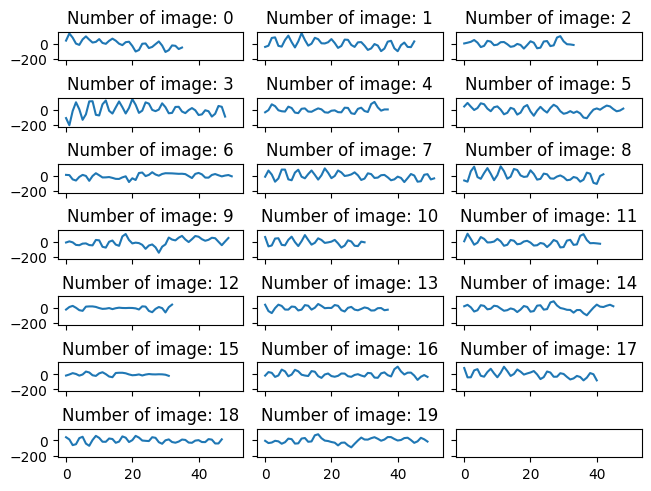

In [14]:
fringe_collection[1].plot()

## Filter out the lowest frequencies

In [6]:
collection_low_ftl = []

for fringe_list in fringe_collection:
    fringe_list_new = fringe_list.filter_low_frq(inplace=False, nl=2)
    collection_low_ftl.append(fringe_list_new)

## Using phase unwraping method

In [7]:
frq_collection = []

for lines in collection_low_ftl:
    num_peaks = lines.count_peaks_of_autocorr()
    num = [i-1 for i in num_peaks]
    lines.filter_low_frq(nl=num)
    lines_Wn = lines.filter_notch_Wn(border=4, updateWn=True, rel_h=0.5, nperseg_c=1, inplace=False)
    frqs = lines_Wn.get_frq(prefilter=False)
    frq_collection.append(frqs)

In [19]:
for frqs in frq_collection:
    print(frqs)

[np.float64(1.5111706853659153), np.float64(1.5369105828803054), np.float64(1.614190436990507), np.float64(1.5691045854785954), np.float64(1.528314285879475), np.float64(1.5655996340453733), np.float64(1.638695829192776), np.float64(1.5376832940888214), np.float64(1.539527410583846), np.float64(1.5649079204114404), np.float64(1.5620401249471543), np.float64(1.5738321973599212), np.float64(1.5865984709085548), np.float64(1.5155519421733576), np.float64(1.6069091289459043), np.float64(1.5741743780109188), np.float64(1.5542462734447182), np.float64(1.5328769936623112), np.float64(1.5809163091302794), np.float64(1.5412537238939235)]
[np.float64(1.477970109689973), np.float64(1.4221488747786772), np.float64(1.3150689786338896), np.float64(1.4399566204213432), np.float64(1.5118142159928787), np.float64(1.4302352873382789), np.float64(1.4713551266616405), np.float64(1.4723596825105627), np.float64(1.4515796625659705), np.float64(1.426769519728782), np.float64(1.404414575638337), np.float64(1.

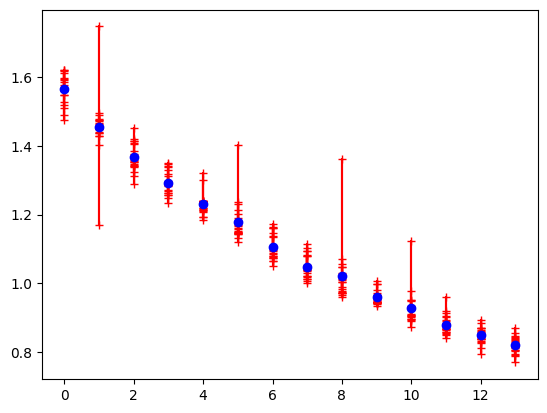

In [17]:
num = len(frq_collection)

plt.figure()

for i, frqs in enumerate(frq_collection):
    plt.plot([i]*len(frqs),frqs, color='red', marker='+')
    plt.plot(i, np.mean(frqs), color='blue', marker='o')

plt.show()

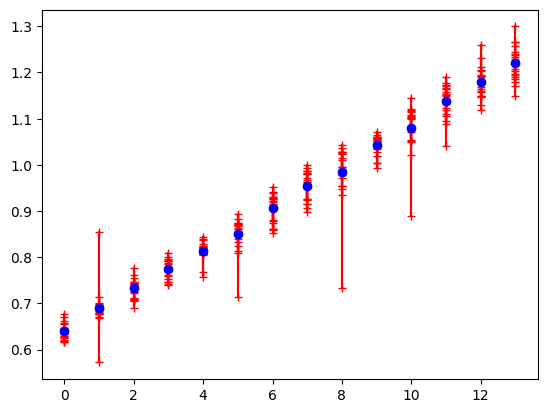

In [16]:
plt.figure()

for i, frqs in enumerate(frq_collection):
    T = [1/f for f in frqs]
    plt.plot([i]*len(frqs),T, color='red', marker = '+')
    plt.plot(i, np.mean(T), color='blue', marker='o')

plt.show()

## Using interpolation
### As initial guess for frequency we take the frequency, acquired by "unwraping" method

In [21]:
frq_cos_collection = []

for lines, frq in zip(collection_low_ftl,frq_collection):

    frqs_cos = lines.get_frq_cos(init_guess_w=frq)
    frq_cos_collection.append(frqs_cos)

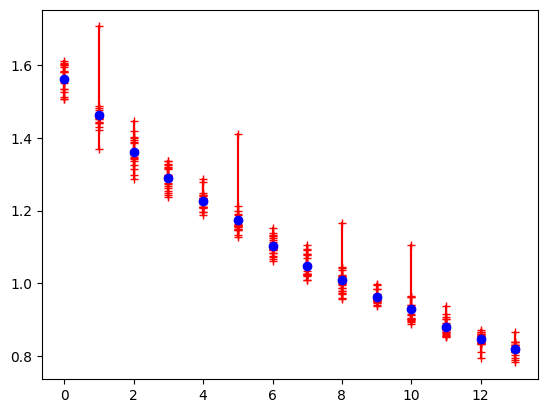

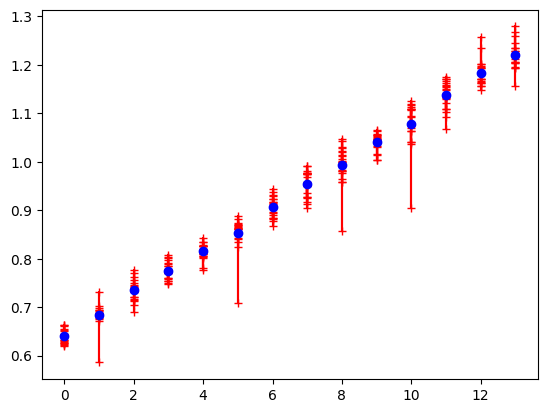

In [23]:
plt.figure()

for i, frqs in enumerate(frq_cos_collection):
    plt.plot([i]*len(frqs),frqs, color='red', marker='+')
    plt.plot(i, np.mean(frqs), color='blue', marker='o')

plt.show()

plt.figure()

for i, frqs in enumerate(frq_cos_collection):
    T = [1/f for f in frqs]
    plt.plot([i]*len(frqs),T, color='red', marker = '+')
    plt.plot(i, np.mean(T), color='blue', marker='o')

plt.show()